In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel(r"C:\Users\KGCAS\Downloads\online+retail (1)\Online Retail.xlsx")

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Display last 5 rows
print("\nLast 5 rows:")
display(df.tail())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Check data types
print("\nData Types:")
print(df.dtypes)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Last 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France



Dataset Shape:
(541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [3]:
# Task 2 – Data Cleaning

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove negative or zero Quantity
df = df[df["Quantity"] > 0]

# Remove invalid UnitPrice
df = df[df["UnitPrice"] > 0]

# Check cleaned dataset
print("\nCleaned Dataset Shape:")
print(df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Cleaned Dataset Shape:
(392692, 8)

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [4]:
# Task 3 – Feature Engineering

# Create TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Extract time features
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

# Create Customer Segment
df["Customer Segment"] = pd.cut(
    df["CustomerID"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

# Create Order Size category
df["Order Size"] = pd.cut(
    df["Quantity"],
    bins=[0, 10, 50, float("inf")],
    labels=["Small", "Medium", "Large"]
)

# Create Day Type
df["Day Type"] = df["InvoiceDate"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# Check the new columns
print("New columns:")
print(df.columns.tolist())

# Display first 5 rows
display(df.head())

New columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour', 'Customer Segment', 'Order Size', 'Day Type']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,Customer Segment,Order Size,Day Type
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,High,Small,Weekday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,High,Small,Weekday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,High,Small,Weekday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,High,Small,Weekday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,High,Small,Weekday


In [5]:
# Task 4 – Data Exploration

# Dataset overview
print("Dataset Information:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Country analysis
print("\nCountry Counts:")
print(df["Country"].value_counts().head(10))

# Unique values
print("\nNumber of Unique Countries:")
print(df["Country"].nunique())

print("\nNumber of Unique Products:")
print(df["StockCode"].nunique())

# Monthly analysis
print("\nSales by Month:")
print(df.groupby("Month")["TotalPrice"].sum().sort_values(ascending=False))

# Country-wise sales
print("\nSales by Country:")
print(df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10))

# Product-wise sales
print("\nTop 10 Products by Sales:")
print(
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         392692 non-null  object        
 1   StockCode         392692 non-null  object        
 2   Description       392692 non-null  object        
 3   Quantity          392692 non-null  int64         
 4   InvoiceDate       392692 non-null  datetime64[ns]
 5   UnitPrice         392692 non-null  float64       
 6   CustomerID        392692 non-null  float64       
 7   Country           392692 non-null  object        
 8   TotalPrice        392692 non-null  float64       
 9   Year              392692 non-null  int32         
 10  Month             392692 non-null  int32         
 11  Day               392692 non-null  int32         
 12  Hour              392692 non-null  int32         
 13  Customer Segment  392692 non-null  category

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,Month,Day,Hour
count,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661



Country Counts:
Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

Number of Unique Countries:
37

Number of Unique Products:
3665

Sales by Month:
Month
11    1156205.610
12    1087613.170
10    1035642.450
9      950690.202
5      677355.150
6      660046.050
8      644051.040
7      598962.901
3      594081.760
1      568101.310
4      468374.331
2      446084.920
Name: TotalPrice, dtype: float64

Sales by Country:
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

T

In [6]:
# Task 5 – Data Wrangling

# 1. Total sales by customer
customer_sales = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Customers by Sales:")
display(customer_sales.head(10))


# 2. Total sales by country
country_sales = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 10 Countries by Sales:")
display(country_sales.head(10))


# 3. Total sales by product
product_sales = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 10 Products by Sales:")
display(product_sales.head(10))


# 4. Monthly sales aggregation
monthly_sales = (
    df.groupby("Month")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("\nMonthly Sales:")
display(monthly_sales)


# 5. Customer order count
customer_orders = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nTop 10 Customers by Number of Orders:")
display(customer_orders.head(10))

Top 10 Customers by Sales:


CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


Top 10 Countries by Sales:


Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64


Top 10 Products by Sales:


Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64


Monthly Sales:


Month
11    1156205.610
12    1087613.170
10    1035642.450
9      950690.202
5      677355.150
6      660046.050
8      644051.040
7      598962.901
3      594081.760
1      568101.310
4      468374.331
2      446084.920
Name: TotalPrice, dtype: float64


Top 10 Customers by Number of Orders:


CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [7]:
# Task 6 – Statistical Analysis

# Select numerical columns
numerical_columns = ["Quantity", "UnitPrice", "TotalPrice"]

# Mean
print("Mean:")
print(df[numerical_columns].mean())

# Median
print("\nMedian:")
print(df[numerical_columns].median())

# Mode
print("\nMode:")
print(df[numerical_columns].mode().iloc[0])

# Standard Deviation
print("\nStandard Deviation:")
print(df[numerical_columns].std())

# Variance
print("\nVariance:")
print(df[numerical_columns].var())

# Percentiles
print("\nPercentiles:")
print(df[numerical_columns].quantile([0.25, 0.50, 0.75]))

Mean:
Quantity      13.119702
UnitPrice      3.125914
TotalPrice    22.631500
dtype: float64

Median:
Quantity       6.00
UnitPrice      1.95
TotalPrice    12.45
dtype: float64

Mode:
Quantity       1.00
UnitPrice      1.25
TotalPrice    15.00
Name: 0, dtype: float64

Standard Deviation:
Quantity      180.492832
UnitPrice      22.241836
TotalPrice    311.099224
dtype: float64

Variance:
Quantity      32577.662399
UnitPrice       494.699251
TotalPrice    96782.727382
dtype: float64

Percentiles:
      Quantity  UnitPrice  TotalPrice
0.25       2.0       1.25        4.95
0.50       6.0       1.95       12.45
0.75      12.0       3.75       19.80


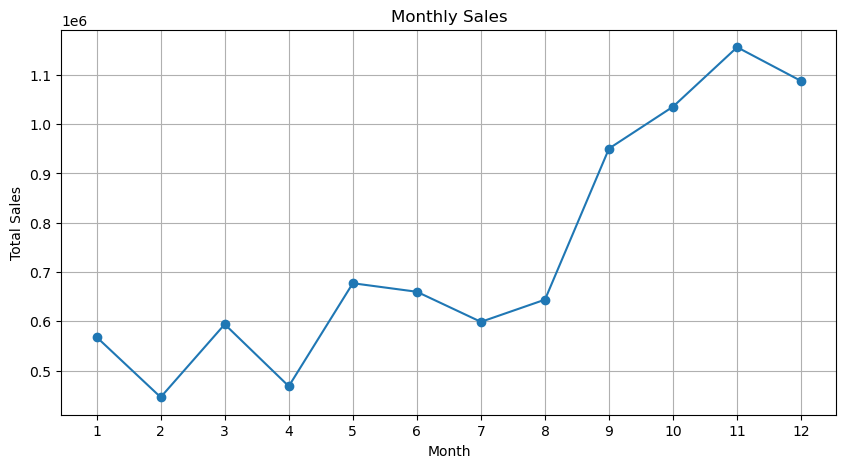

In [8]:
# Task 7.1 – Line Chart

monthly_sales = df.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

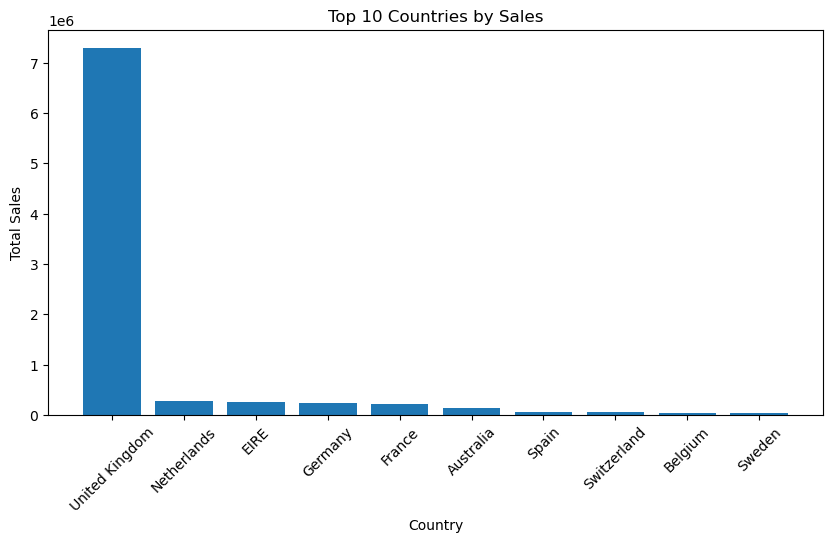

In [9]:
# Task 7.2 – Bar Chart

country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(country_sales.index, country_sales.values)
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

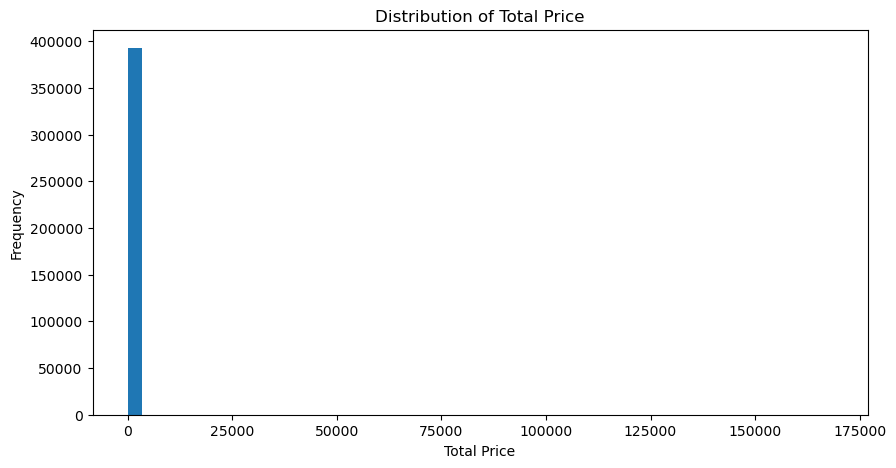

In [10]:
# Task 7.3 – Histogram

plt.figure(figsize=(10, 5))
plt.hist(df["TotalPrice"], bins=50)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

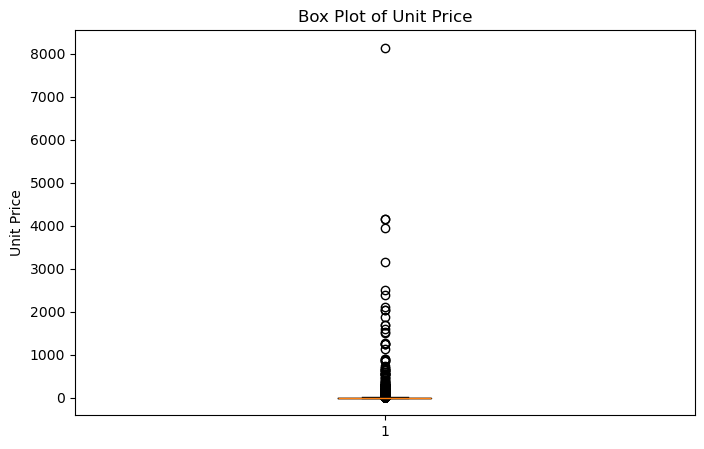

In [11]:
# Task 7.4 – Box Plot

plt.figure(figsize=(8, 5))
plt.boxplot(df["UnitPrice"])
plt.title("Box Plot of Unit Price")
plt.ylabel("Unit Price")
plt.show()

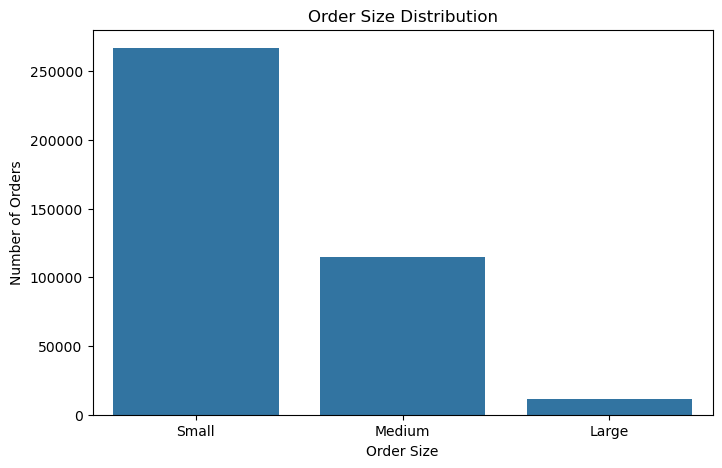

In [12]:
# Task 7.5 – Seaborn Count Plot

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Order Size")

plt.title("Order Size Distribution")
plt.xlabel("Order Size")
plt.ylabel("Number of Orders")
plt.show()

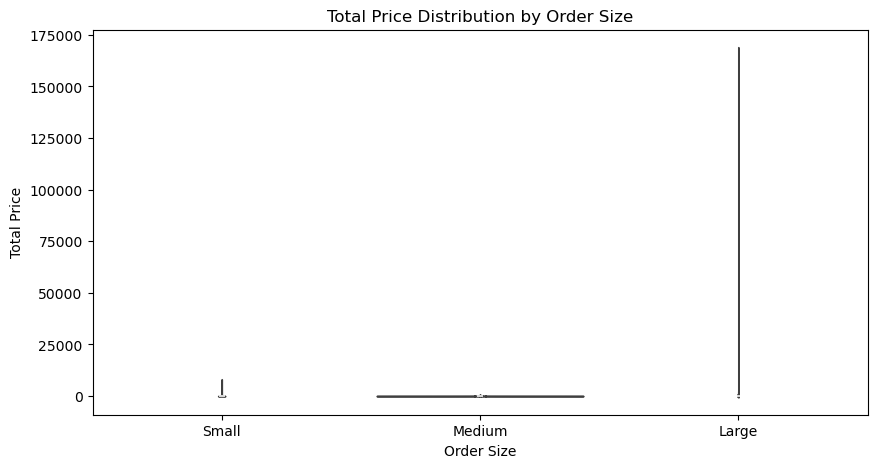

In [13]:
# Task 7.6 – Seaborn Violin Plot

plt.figure(figsize=(10, 5))

sns.violinplot(
    data=df,
    x="Order Size",
    y="TotalPrice"
)

plt.title("Total Price Distribution by Order Size")
plt.xlabel("Order Size")
plt.ylabel("Total Price")
plt.show()

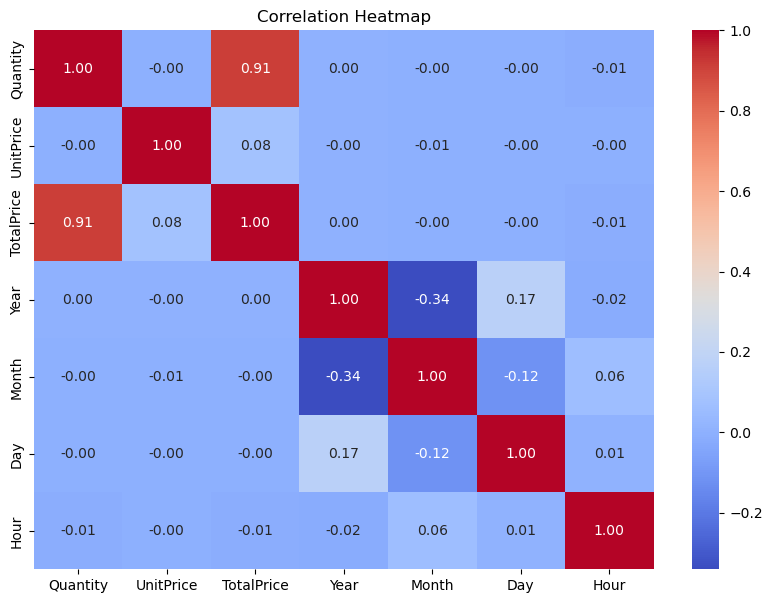

In [14]:
# Task 7.7 – Seaborn Heatmap

plt.figure(figsize=(10, 7))

correlation = df[
    ["Quantity", "UnitPrice", "TotalPrice", "Year", "Month", "Day", "Hour"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

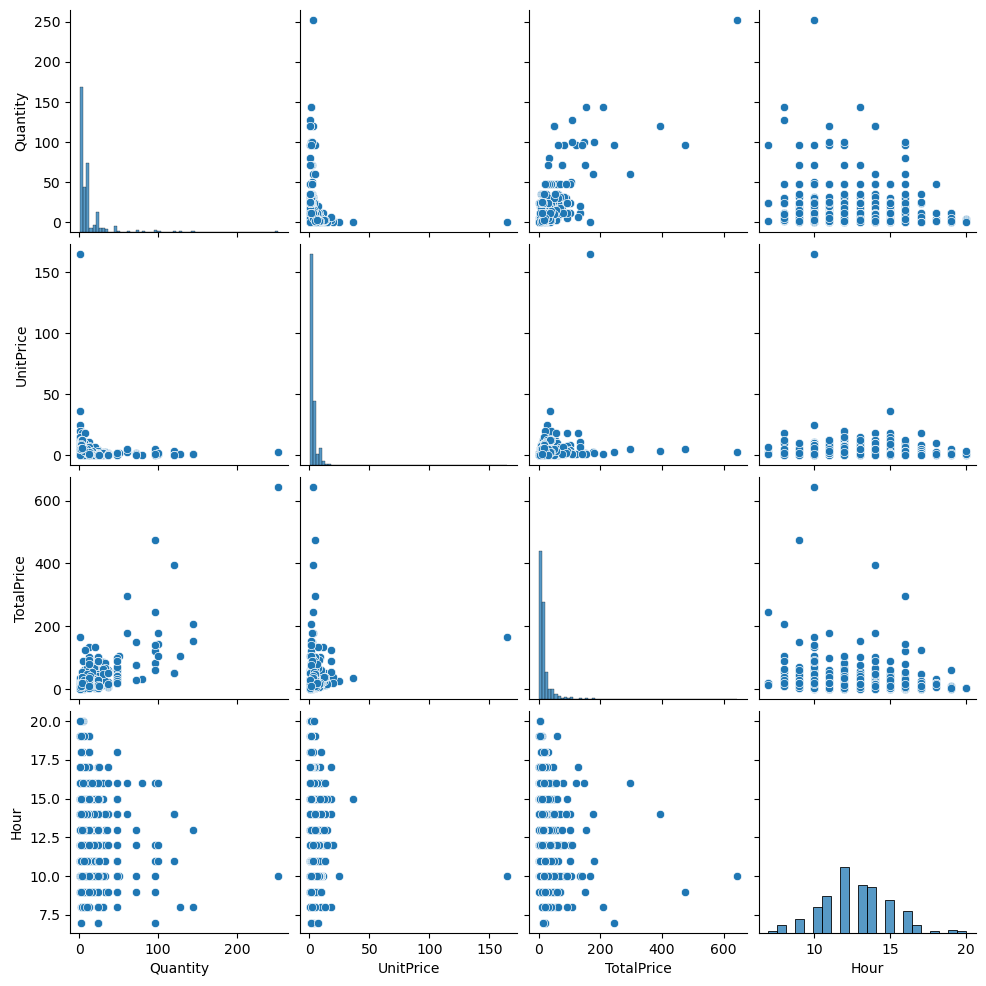

In [15]:
# Task 7.8 – Seaborn Pair Plot

sample_df = df[
    ["Quantity", "UnitPrice", "TotalPrice", "Hour"]
].sample(1000, random_state=42)

sns.pairplot(sample_df)

plt.show()

In [16]:
# Task 8.1 – Top Country by Sales

top_country = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)

print("Top Country by Sales:")
print(top_country.head(5))

Top Country by Sales:
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Name: TotalPrice, dtype: float64


In [17]:
# Task 8.2 – Best Sales Month

monthly_sales = (
    df.groupby("Month")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Month:")
print(monthly_sales)

print("\nBest Sales Month:")
print(monthly_sales.idxmax())

print("Highest Sales:")
print(monthly_sales.max())

Sales by Month:
Month
11    1156205.610
12    1087613.170
10    1035642.450
9      950690.202
5      677355.150
6      660046.050
8      644051.040
7      598962.901
3      594081.760
1      568101.310
4      468374.331
2      446084.920
Name: TotalPrice, dtype: float64

Best Sales Month:
11
Highest Sales:
1156205.61


In [18]:
# Task 8.3 – Peak Sales Time

hourly_sales = (
    df.groupby("Hour")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Hour:")
print(hourly_sales)

print("\nPeak Sales Hour:")
print(hourly_sales.idxmax())

print("Highest Sales:")
print(hourly_sales.max())

Sales by Hour:
Hour
12    1373695.390
10    1259267.591
13    1168724.200
11    1101177.600
14     991992.821
15     963559.680
9      842392.341
16     467380.560
8      281997.790
17     233811.591
18     104744.990
19      48568.400
7       31059.210
20      18832.480
6           4.250
Name: TotalPrice, dtype: float64

Peak Sales Hour:
12
Highest Sales:
1373695.39


In [19]:
# Task 8.4 – Customer Behavior

print("Customer Behavior by Order Size:")

customer_behavior = (
    df.groupby("Order Size", observed=True)
    .agg(
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Sales=("TotalPrice", "sum"),
        Average_Order_Value=("TotalPrice", "mean")
    )
)

print(customer_behavior)

Customer Behavior by Order Size:
            Total_Orders  Total_Sales  Average_Order_Value
Order Size                                                
Small              15901  3070687.204            11.512904
Medium             15177  3112114.540            27.208555
Large               3893  2704407.150           233.239082


In [20]:
# Task 8.5 – High-Value Customers

high_value_customers = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 High-Value Customers:")
print(high_value_customers.head(10))

Top 10 High-Value Customers:
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


In [21]:
# Task 8.6 – Top Products by Sales

top_products = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Products by Sales:")
print(top_products.head(10))

Top 10 Products by Sales:
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64
